In [1]:
# Importations TensorFlow/Keras, SciKit-Learn, PIL, OS, NumPy, OpenCV, Matplotlib
from google.colab import drive
import tensorflow as tf
from tensorflow.keras import layers, models, backend as K
from tensorflow.keras.metrics import Recall, AUC # Métriques Keras intégrées
from sklearn.model_selection import train_test_split
from PIL import Image
import os
import numpy as np
import random
import cv2
import matplotlib.pyplot as plt
import time # Pour mesurer le temps

# Importations pour métriques post-entraînement
from scipy.spatial.distance import directed_hausdorff # Pour Hausdorff

# Montage Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Fonctions d'augmentation (rotateImage, bruit, change_gamma, color, random_change)

def rotateImage(image, angle):
    image_center = tuple(np.array(image.shape[1::-1])/2)
    rot_mat = cv2.getRotationMatrix2D(image_center, angle, 1.0)
    return cv2.warpAffine(image, rot_mat, image.shape[1::-1], flags=cv2.INTER_LINEAR)

def bruit(image):
    image_float = image.astype(np.float32)
    noise = np.random.randn(*image.shape) * random.randint(5, 30)
    noisy_image = np.clip(image_float + noise, 0, 255)
    return noisy_image.astype(np.uint8)

def change_gamma(image, alpha=1.0, beta=0.0):
    # Ajuste la luminosité (beta) et le contraste (alpha)
    image_float = image.astype(np.float32)
    adjusted_image = np.clip(alpha * image_float + beta, 0, 255)
    return adjusted_image.astype(np.uint8)

def color(image, alpha=20):
    # Ajoute une variation de couleur aléatoire
    variation = np.random.randint(-alpha, alpha + 1, size=image.shape, dtype=np.int32)
    colored_image = np.clip(image.astype(np.int32) + variation, 0, 255)
    return colored_image.astype(np.uint8)

def random_change(image):
    # Applique aléatoirement certaines transformations
    img = image.copy() # Travaille sur une copie
    if np.random.randint(2):
        img = change_gamma(img, random.uniform(0.8, 1.2), np.random.randint(-50, 50))
    if np.random.randint(2):
        img = bruit(img)
    if np.random.randint(2):
        img = color(img)
    return img

In [3]:
# --- Fonction Dice Coefficient  ---
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# --- Modèle U-Net ---
def model(nbr):
    entree = layers.Input(shape=(576, 560, 3), dtype='float32')

    # Encodeur
    conv1 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(entree)
    conv1 = layers.BatchNormalization()(conv1)
    conv1 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(conv1)
    bn1 = layers.BatchNormalization()(conv1)
    pool1 = layers.MaxPool2D()(bn1)

    conv2 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(pool1)
    conv2 = layers.BatchNormalization()(conv2)
    conv2 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(conv2)
    bn2 = layers.BatchNormalization()(conv2)
    pool2 = layers.MaxPool2D()(bn2)

    conv3 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(pool2)
    conv3 = layers.BatchNormalization()(conv3)
    conv3 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(conv3)
    bn3 = layers.BatchNormalization()(conv3)
    pool3 = layers.MaxPool2D()(bn3)

    conv4a = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(pool3)
    conv4a = layers.BatchNormalization()(conv4a)
    conv4a = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(conv4a)
    bn4 = layers.BatchNormalization()(conv4a)
    pool4 = layers.MaxPool2D()(bn4)

    # Bottleneck (8*nbr puis 4*nbr)
    conv_mid = layers.Conv2D(8 * nbr, 3, activation='relu', padding='same')(pool4)
    conv_mid = layers.BatchNormalization()(conv_mid)
    conv_mid = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(conv_mid)
    bn_mid = layers.BatchNormalization()(conv_mid)

    # Décodeur
    up1 = layers.UpSampling2D()(bn_mid)
    concat1 = layers.Concatenate(axis=3)([up1, bn4]) # Skip connection depuis bn4
    # Blocs Conv après concat (8*nbr puis 4*nbr )
    dconv1 = layers.Conv2D(8 * nbr, 3, activation='relu', padding='same')(concat1)
    dconv1 = layers.BatchNormalization()(dconv1)
    dconv1 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(dconv1)
    dbn1 = layers.BatchNormalization()(dconv1)

    up2 = layers.UpSampling2D()(dbn1)
    concat2 = layers.Concatenate(axis=3)([up2, bn3]) # Skip connection depuis bn3
    # Blocs Conv après concat (4*nbr puis 2*nbr )
    dconv2 = layers.Conv2D(4 * nbr, 3, activation='relu', padding='same')(concat2)
    dconv2 = layers.BatchNormalization()(dconv2)
    dconv2 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(dconv2)
    dbn2 = layers.BatchNormalization()(dconv2)

    up3 = layers.UpSampling2D()(dbn2)
    concat3 = layers.Concatenate(axis=3)([up3, bn2]) # Skip connection depuis bn2
    # Blocs Conv après concat (2*nbr puis nbr )
    dconv3 = layers.Conv2D(2 * nbr, 3, activation='relu', padding='same')(concat3)
    dconv3 = layers.BatchNormalization()(dconv3)
    dconv3 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(dconv3)
    dbn3 = layers.BatchNormalization()(dconv3)

    up4 = layers.UpSampling2D()(dbn3)
    concat4 = layers.Concatenate(axis=3)([up4, bn1]) # Skip connection depuis bn1
    # Blocs Conv après concat (nbr puis nbr)
    dconv4 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(concat4)
    dconv4 = layers.BatchNormalization()(dconv4)
    dconv4 = layers.Conv2D(nbr, 3, activation='relu', padding='same')(dconv4)
    dbn4 = layers.BatchNormalization()(dconv4)

    # Couche de sortie
    sortie = layers.Conv2D(1, 1, activation='sigmoid', padding='same')(dbn4)

    return models.Model(inputs=entree, outputs=sortie)


# --- Nouvelles métriques Keras personnalisées ---

def iou_coef(y_true, y_pred, smooth=1e-6):
    """Coefficient IoU (Intersection over Union) ou Indice de Jaccard."""
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    iou = (intersection + smooth) / (union + smooth)
    return iou


def specificity(y_true, y_pred):
    """Spécificité (True Negative Rate)."""
    neg_y_true = 1 - y_true
    neg_y_pred = 1 - y_pred
    fp = K.sum(K.cast(K.greater(y_pred, 0.5), 'float32') * K.cast(K.equal(y_true, 0), 'float32'))
    tn = K.sum(K.cast(K.less_equal(y_pred, 0.5), 'float32') * K.cast(K.equal(y_true, 0), 'float32'))
    specificity_val = tn / (tn + fp + K.epsilon())
    return specificity_val

In [4]:
# Chemins vers les données
dir_images = '/content/drive/MyDrive/DRIVE/training/images/'
dir_mask   = '/content/drive/MyDrive/DRIVE/training/1st_manual/'

# Vérification existence dossiers
if not os.path.isdir(dir_images):
    raise ValueError(f"Le dossier d'images n'existe pas : {dir_images}")
if not os.path.isdir(dir_mask):
    raise ValueError(f"Le dossier de masques n'existe pas : {dir_mask}")

tab_images, tab_masks = [], []
target_height, target_width = 576, 560

print("Chargement et augmentation des données...")

# Boucle de chargement et d'augmentation
for fichier in sorted(os.listdir(dir_images)):
    if fichier.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
        try:
            img_path = os.path.join(dir_images, fichier)
            img_orig = cv2.imread(img_path)
            if img_orig is None: continue
            img_orig = img_orig[:target_height, :target_width]
            if img_orig.shape[0] != target_height or img_orig.shape[1] != target_width:
                img_orig = cv2.resize(img_orig, (target_width, target_height), interpolation=cv2.INTER_AREA)

            num = fichier.split('_')[0]
            file_mask = os.path.join(dir_mask, num + '_manual1.gif')
            if not os.path.exists(file_mask): continue

            img_mask_orig = np.array(Image.open(file_mask))
            if len(img_mask_orig.shape) == 3: img_mask_orig = img_mask_orig[:,:,0]
            img_mask_orig = img_mask_orig[:target_height, :target_width]
            if img_mask_orig.shape[0] != target_height or img_mask_orig.shape[1] != target_width:
                 img_mask_orig = cv2.resize(img_mask_orig, (target_width, target_height), interpolation=cv2.INTER_NEAREST)

            tab_images.append(img_orig)
            tab_masks.append(img_mask_orig)

            for angle in [0, 90, 180, 270]:
                img_r = rotateImage(img_orig, angle)
                mask_rot_mat = cv2.getRotationMatrix2D(tuple(np.array(img_mask_orig.shape[1::-1])/2), angle, 1.0)
                img_mask_r = cv2.warpAffine(img_mask_orig, mask_rot_mat, img_mask_orig.shape[1::-1], flags=cv2.INTER_NEAREST)

                for flip_code in [-1, 0, 1]:
                    for flip in [0, 1]:
                        if flip_code == -1 and flip == 0:
                            img_f = cv2.flip(img_r, -1)
                            img_mask_f = cv2.flip(img_mask_r, -1)
                        elif flip_code != -1 and flip == 1:
                            img_f = cv2.flip(img_r, flip_code)
                            img_mask_f = cv2.flip(img_mask_r, flip_code)
                        else:
                            img_f = img_r.copy()
                            img_mask_f = img_mask_r.copy()


                        img_augmented = random_change(img_f)
                        img_augmented = img_augmented[:target_height, :target_width]
                        img_mask_final = img_mask_f[:target_height, :target_width]

                        if img_augmented.shape[0] == target_height and img_augmented.shape[1] == target_width and \
                           img_mask_final.shape[0] == target_height and img_mask_final.shape[1] == target_width:
                              tab_images.append(img_augmented)
                              tab_masks.append(img_mask_final)

        except Exception as e:
            print(f"Erreur pendant chargement/augmentation pour {fichier}: {e}")

if len(tab_images) > 500:
    print(f"Attention: Plus de 500 images générées ({len(tab_images)}), limitation à 500.")
    indices = random.sample(range(len(tab_images)), 500)
    tab_images = [tab_images[i] for i in indices]
    tab_masks = [tab_masks[i] for i in indices]

print(f"Chargement et augmentation terminés. Nombre total d'échantillons: {len(tab_images)}")
if not tab_images:
     raise SystemExit("Erreur: Aucune image/masque après chargement/augmentation.")

tab_images = np.array(tab_images, dtype=np.float32) / 255.0
tab_masks = np.array(tab_masks, dtype=np.float32) / 255.0
if len(tab_masks.shape) == 3:
    tab_masks = np.expand_dims(tab_masks, axis=-1)
    print(f"Dimension de canal ajoutée aux masques. Nouvelle forme : {tab_masks.shape}")

print(f"Forme finale des images : {tab_images.shape}")
print(f"Forme finale des masques : {tab_masks.shape}")

# Séparer les jeux de données (Création des ensembles d'entraînement, validation et test)
# 80% train, 15% validation, 5% test
train_images, test_val_images, train_masks, test_val_masks = train_test_split(
    tab_images, tab_masks, test_size=0.2, random_state=123 # 80% train, 20% pour test+val
)
val_images, test_images, val_masks, test_masks = train_test_split(
    test_val_images, test_val_masks, test_size=0.25, random_state=123 # 25% de 20% -> 5% test, reste 15% val
)


print(f"\nDonnées divisées :")
print(f"  Entraînement : {train_images.shape[0]} images, {train_masks.shape[0]} masques")
print(f"  Validation : {val_images.shape[0]} images, {val_masks.shape[0]} masques")
print(f"  Test : {test_images.shape[0]} images, {test_masks.shape[0]} masques")

# Libérer la mémoire
del tab_images, tab_masks, test_val_images, test_val_masks

Chargement et augmentation des données...
Chargement et augmentation terminés. Nombre total d'échantillons: 500
Dimension de canal ajoutée aux masques. Nouvelle forme : (500, 576, 560, 1)
Forme finale des images : (500, 576, 560, 3)
Forme finale des masques : (500, 576, 560, 1)

Données divisées :
  Entraînement : 400 images, 400 masques
  Validation : 75 images, 75 masques
  Test : 25 images, 25 masques


In [5]:
my_model = model(64) # Crée le modèle U-Net standard avec 64 filtres de base

# Compiler le modèle avec les métriques ajoutées
my_model.compile(optimizer='adam',                 # optimiseur
                 loss='binary_crossentropy',       #  fonction de perte
                 metrics=['accuracy',
                          dice_coef,
                          iou_coef,                #  IoU / Jaccard
                          Recall(name='sensitivity'), #  Sensitivity (Recall)
                          specificity,             #  Specificity
                          AUC(name='auc_roc')      #  AUC-ROC
                          ])

# Afficher le résumé du modèle qui sera entraîné
print("\nRésumé du modèle U-Net qui sera entraîné :")
my_model.summary()


Résumé du modèle U-Net qui sera entraîné :


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 576, 560,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 576, 560,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 576, 560,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 576, 560,  │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 576, 560,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 288, 280,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 288, 280,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 280,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 288, 280,  │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 288, 280,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 144, 140,  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 144, 140,  │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 140,  │      1,024 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 144, 140,  │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 144, 140,  │      1,024 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 72, 70,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 72, 70,    │    590,080 │ max_pooling2d_2[

 Total params: 10,194,497 (38.89 MB)

 Trainable params: 10,187,201 (38.86 MB)

 Non-trainable params: 7,296 (28.50 KB)

In [6]:
# --- AJOUT DES CALLBACKS ---
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

checkpoint_filepath_simple = '/content/drive/MyDrive/best-SIMPLE.h5'

early_stopping = EarlyStopping(monitor='val_dice_coef', patience=15, verbose=1, mode='max', restore_best_weights=True)

model_checkpoint = ModelCheckpoint(filepath=checkpoint_filepath_simple,
                                   save_weights_only=False,
                                   monitor='val_dice_coef',
                                   mode='max',
                                   save_best_only=True,
                                   verbose=1)

# --- PARAMETRES D'ENTRAINEMENT ---
EPOCHS = 80
BATCH_SIZE = 3

print(f"\n--- Début de l'entraînement ({EPOCHS} époques, batch size {BATCH_SIZE}) ---")
print(f"Early Stopping surveille '{early_stopping.monitor}' ({early_stopping.mode}) avec patience {early_stopping.patience}.")
print(f"Model Checkpoint sauvegardera le meilleur modèle selon '{model_checkpoint.monitor}' dans '{checkpoint_filepath_simple}'.")

start_training_time = time.time()

# Entraîner le modèle avec les callbacks
history = my_model.fit(train_images, train_masks,
                       epochs=EPOCHS,
                       batch_size=BATCH_SIZE,
                       validation_data=(val_images, val_masks),
                       callbacks=[early_stopping, model_checkpoint],
                       verbose=1)

end_training_time = time.time()
training_runtime = end_training_time - start_training_time
print(f"\n--- Entraînement terminé (potentiellement avant {EPOCHS} époques grâce à EarlyStopping) ---")
print(f"Temps d'exécution total de l'entraînement (Runtime) : {training_runtime:.2f} secondes ({training_runtime/60:.2f} minutes)")
print(f"Le meilleur modèle a été sauvegardé à : {checkpoint_filepath_simple}")



--- Début de l'entraînement (80 époques, batch size 3) ---
Early Stopping surveille 'val_dice_coef' (max) avec patience 15.
Model Checkpoint sauvegardera le meilleur modèle selon 'val_dice_coef' dans '/content/drive/MyDrive/best-SIMPLE.h5'.
Epoch 1/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 850ms/step - accuracy: 0.7499 - auc_roc: 0.7456 - dice_coef: 0.2053 - iou_coef: 0.1149 - loss: 0.5803 - sensitivity: 0.6020 - specificity: 0.7642
Epoch 1: val_dice_coef improved from -inf to 0.20547, saving model to /content/drive/MyDrive/best-SIMPLE.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 239s 1s/step - accuracy: 0.7506 - auc_roc: 0.7460 - dice_coef: 0.2056 - iou_coef: 0.1151 - loss: 0.5793 - sensitivity: 0.6015 - specificity: 0.7650 - val_accuracy: 0.7670 - val_auc_roc: 0.7420 - val_dice_coef: 0.2055 - val_iou_coef: 0.1146 - val_loss: 2.7913 - val_sensitivity: 0.4064 - val_specificity: 0.8020
Epoch 2/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.9388 - auc_roc: 0.9002 - dice_coef: 0.3861 - iou_coef: 0.2404 - loss: 0.2196 - sensitivity: 0.4814 - specificity: 0.9836
Epoch 2: val_dice_coef did not improve from 0.20547
134/134 ━━━━━━━━━━━━━━━━━━━━ 125s 660ms/step - accuracy: 0.9389 - auc_roc: 0.9003 - dice_coef: 0.3863 - iou_coef: 0.2406 - loss: 0.2194 - sensitivity: 0.4815 - specificity: 0.9836 - val_accuracy: 0.9025 - val_auc_roc: 0.7555 - val_dice_coef: 0.1245 - val_iou_coef: 0.0664 - val_loss: 0.2912 - val_sensitivity: 0.0196 - val_specificity: 0.9878
Epoch 3/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 621ms/step - accuracy: 0.9469 - a

134/134 ━━━━━━━━━━━━━━━━━━━━ 148s 708ms/step - accuracy: 0.9469 - auc_roc: 0.9349 - dice_coef: 0.4958 - iou_coef: 0.3304 - loss: 0.1586 - sensitivity: 0.5329 - specificity: 0.9872 - val_accuracy: 0.9058 - val_auc_roc: 0.7984 - val_dice_coef: 0.2199 - val_iou_coef: 0.1238 - val_loss: 0.2643 - val_sensitivity: 0.1180 - val_specificity: 0.9820
Epoch 4/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9516 - auc_roc: 0.9454 - dice_coef: 0.5535 - iou_coef: 0.3839 - loss: 0.1395 - sensitivity: 0.5750 - specificity: 0.9879
Epoch 4: val_dice_coef improved from 0.21995 to 0.37157, saving model to /content/drive/MyDrive/best-SIMPLE.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 138s 678ms/step - accuracy: 0.9516 - auc_roc: 0.9454 - dice_coef: 0.5536 - iou_coef: 0.3840 - loss: 0.1395 - sensitivity: 0.5751 - specificity: 0.9879 - val_accuracy: 0.9310 - val_auc_roc: 0.8994 - val_dice_coef: 0.3716 - val_iou_coef: 0.2292 - val_loss: 0.2027 - val_sensitivity: 0.2518 - val_specificity: 0.9966
Epoch 5/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9557 - auc_roc: 0.9557 - dice_coef: 0.6026 - iou_coef: 0.4325 - loss: 0.1256 - sensitivity: 0.6279 - specificity: 0.9875
Epoch 5: val_dice_coef improved from 0.37157 to 0.50292, saving model to /content/drive/MyDrive/best-SIMPLE.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 142s 678ms/step - accuracy: 0.9557 - auc_roc: 0.9556 - dice_coef: 0.6026 - iou_coef: 0.4325 - loss: 0.1256 - sensitivity: 0.6279 - specificity: 0.9875 - val_accuracy: 0.9487 - val_auc_roc: 0.9441 - val_dice_coef: 0.5029 - val_iou_coef: 0.3373 - val_loss: 0.1443 - val_sensitivity: 0.4699 - val_specificity: 0.9950
Epoch 6/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9562 - auc_roc: 0.9571 - dice_coef: 0.6107 - iou_coef: 0.4407 - loss: 0.1233 - sensitivity: 0.6308 - specificity: 0.9879
Epoch 6: val_dice_coef improved from 0.50292 to 0.50496, saving model to /content/drive/MyDrive/best-SIMPLE.h5


...

134/134 ━━━━━━━━━━━━━━━━━━━━ 147s 701ms/step - accuracy: 0.9892 - auc_roc: 0.9986 - dice_coef: 0.9121 - iou_coef: 0.8386 - loss: 0.0252 - sensitivity: 0.9371 - specificity: 0.9942 - val_accuracy: 0.9697 - val_auc_roc: 0.9481 - val_dice_coef: 0.8075 - val_iou_coef: 0.6796 - val_loss: 0.1326 - val_sensitivity: 0.8072 - val_specificity: 0.9854
Epoch 67/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9891 - auc_roc: 0.9986 - dice_coef: 0.9126 - iou_coef: 0.8393 - loss: 0.0253 - sensitivity: 0.9394 - specificity: 0.9940
Epoch 67: val_dice_coef did not improve from 0.80747
134/134 ━━━━━━━━━━━━━━━━━━━━ 137s 661ms/step - accuracy: 0.9891 - auc_roc: 0.9986 - dice_coef: 0.9126 - iou_coef: 0.8393 - loss: 0.0253 - sensitivity: 0.9394 - specificity: 0.9940 - val_accuracy: 0.9693 - val_auc_roc: 0.9491 - val_dice_coef: 0.8017 - val_iou_coef: 0.6717 - val_loss: 0.1294 - val_sensitivity: 0.7975 - val_specificity: 0.9859
Epoch 68/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.98

134/134 ━━━━━━━━━━━━━━━━━━━━ 148s 711ms/step - accuracy: 0.9892 - auc_roc: 0.9986 - dice_coef: 0.9131 - iou_coef: 0.8402 - loss: 0.0251 - sensitivity: 0.9381 - specificity: 0.9942 - val_accuracy: 0.9697 - val_auc_roc: 0.9491 - val_dice_coef: 0.8075 - val_iou_coef: 0.6797 - val_loss: 0.1320 - val_sensitivity: 0.8093 - val_specificity: 0.9852
Epoch 69/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.9893 - auc_roc: 0.9986 - dice_coef: 0.9137 - iou_coef: 0.8413 - loss: 0.0250 - sensitivity: 0.9391 - specificity: 0.9942
Epoch 69: val_dice_coef did not improve from 0.80754
134/134 ━━━━━━━━━━━━━━━━━━━━ 135s 662ms/step - accuracy: 0.9893 - auc_roc: 0.9986 - dice_coef: 0.9137 - iou_coef: 0.8413 - loss: 0.0250 - sensitivity: 0.9391 - specificity: 0.9942 - val_accuracy: 0.9705 - val_auc_roc: 0.9425 - val_dice_coef: 0.8066 - val_iou_coef: 0.6784 - val_loss: 0.1370 - val_sensitivity: 0.7756 - val_specificity: 0.9893
Epoch 70/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.98

134/134 ━━━━━━━━━━━━━━━━━━━━ 148s 706ms/step - accuracy: 0.9895 - auc_roc: 0.9987 - dice_coef: 0.9160 - iou_coef: 0.8452 - loss: 0.0244 - sensitivity: 0.9403 - specificity: 0.9943 - val_accuracy: 0.9699 - val_auc_roc: 0.9488 - val_dice_coef: 0.8076 - val_iou_coef: 0.6801 - val_loss: 0.1304 - val_sensitivity: 0.8035 - val_specificity: 0.9860
Epoch 71/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9898 - auc_roc: 0.9987 - dice_coef: 0.9178 - iou_coef: 0.8482 - loss: 0.0239 - sensitivity: 0.9418 - specificity: 0.9945
Epoch 71: val_dice_coef improved from 0.80764 to 0.80848, saving model to /content/drive/MyDrive/best-SIMPLE.h5


134/134 ━━━━━━━━━━━━━━━━━━━━ 141s 703ms/step - accuracy: 0.9898 - auc_roc: 0.9987 - dice_coef: 0.9178 - iou_coef: 0.8482 - loss: 0.0238 - sensitivity: 0.9418 - specificity: 0.9945 - val_accuracy: 0.9704 - val_auc_roc: 0.9444 - val_dice_coef: 0.8085 - val_iou_coef: 0.6812 - val_loss: 0.1356 - val_sensitivity: 0.7874 - val_specificity: 0.9881
Epoch 72/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - accuracy: 0.9901 - auc_roc: 0.9988 - dice_coef: 0.9205 - iou_coef: 0.8528 - loss: 0.0231 - sensitivity: 0.9446 - specificity: 0.9946
Epoch 72: val_dice_coef did not improve from 0.80848
134/134 ━━━━━━━━━━━━━━━━━━━━ 89s 661ms/step - accuracy: 0.9901 - auc_roc: 0.9988 - dice_coef: 0.9205 - iou_coef: 0.8528 - loss: 0.0231 - sensitivity: 0.9446 - specificity: 0.9946 - val_accuracy: 0.9690 - val_auc_roc: 0.9395 - val_dice_coef: 0.8012 - val_iou_coef: 0.6709 - val_loss: 0.1473 - val_sensitivity: 0.7781 - val_specificity: 0.9875
Epoch 73/80
134/134 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.990

134/134 ━━━━━━━━━━━━━━━━━━━━ 95s 708ms/step - accuracy: 0.9907 - auc_roc: 0.9989 - dice_coef: 0.9243 - iou_coef: 0.8593 - loss: 0.0219 - sensitivity: 0.9465 - specificity: 0.9950 - val_accuracy: 0.9711 - val_auc_roc: 0.9387 - val_dice_coef: 0.8128 - val_iou_coef: 0.6874 - val_loss: 0.1468 - val_sensitivity: 0.7788 - val_specificity: 0.9897
Restoring model weights from the end of the best epoch: 80.

--- Entraînement terminé (potentiellement avant 80 époques grâce à EarlyStopping) ---
Temps d'exécution total de l'entraînement (Runtime) : 10736.25 secondes (178.94 minutes)
Le meilleur modèle a été sauvegardé à : /content/drive/MyDrive/best-SIMPLE.h5



--- Génération des graphiques de l'historique d'entraînement ---


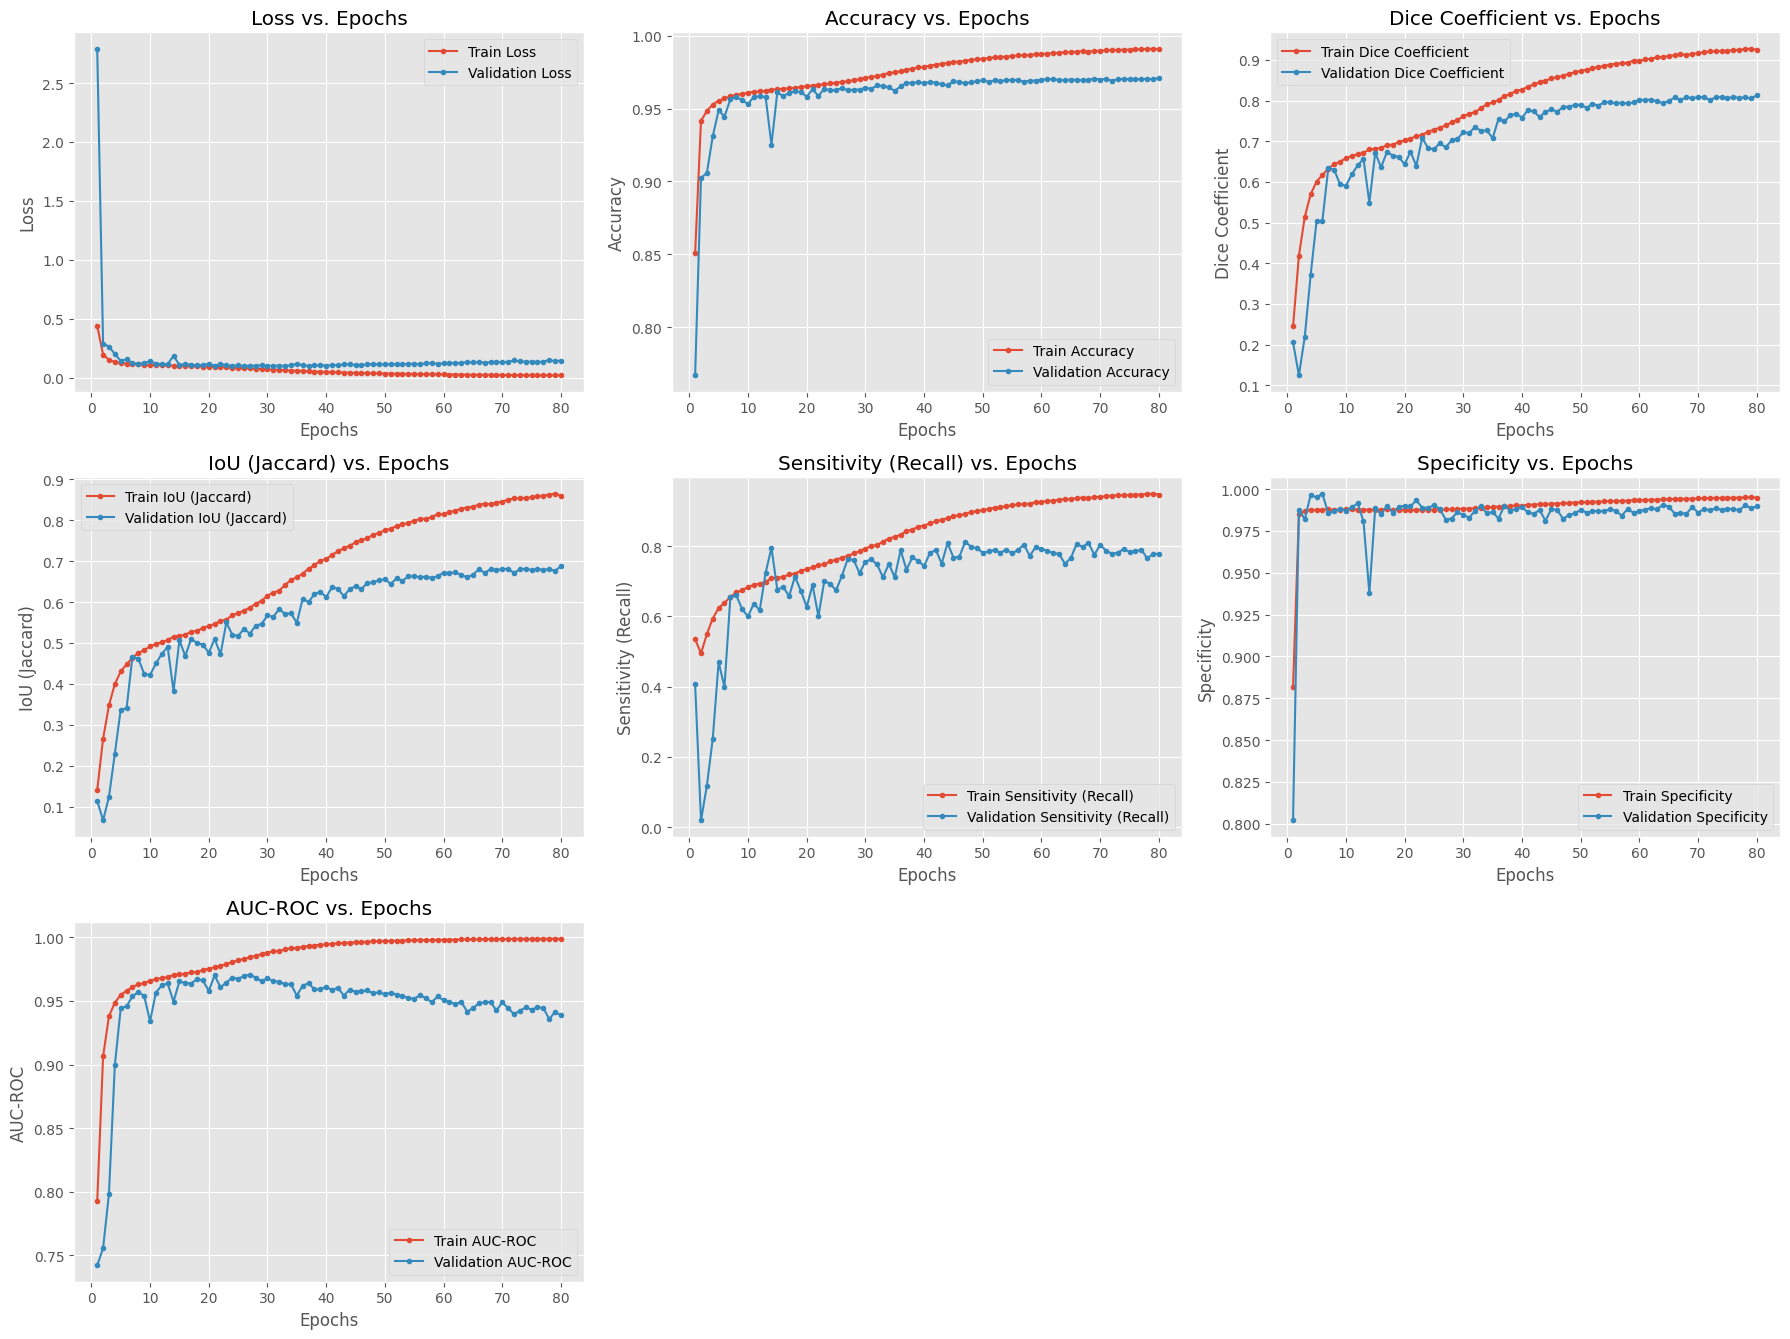


--- Valeurs finales des métriques (dernière époque effectuée / meilleure époque si restore_best_weights=True) ---
--- Loss ---
  Train      : 0.0217
  Validation : 0.1468
--- Accuracy ---
  Train      : 0.9907
  Validation : 0.9711
--- Dice Coefficient ---
  Train      : 0.9248
  Validation : 0.8128
--- IoU (Jaccard) ---
  Train      : 0.8602
  Validation : 0.6874
--- Sensitivity (Recall) ---
  Train      : 0.9469
  Validation : 0.7788
--- Specificity ---
  Train      : 0.9950
  Validation : 0.9897
--- AUC-ROC ---
  Train      : 0.9989
  Validation : 0.9387


In [7]:
print("\n--- Génération des graphiques de l'historique d'entraînement ---")

history_dict = history.history

metrics_to_plot = {
    'loss': 'Loss',
    'accuracy': 'Accuracy',
    'dice_coef': 'Dice Coefficient',
    'iou_coef': 'IoU (Jaccard)',
    'sensitivity': 'Sensitivity (Recall)',
    'specificity': 'Specificity',
    'auc_roc': 'AUC-ROC'
}

num_metrics = len(metrics_to_plot)
num_cols = 3
num_rows = (num_metrics + num_cols - 1) // num_cols

plt.style.use('ggplot')
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(num_cols * 6, num_rows * 4.5))
axes = axes.flatten()

plot_index = 0
for metric_key, metric_name in metrics_to_plot.items():
    if plot_index >= len(axes): break
    ax = axes[plot_index]
    if metric_key in history_dict:
        epochs_range = range(1, len(history_dict[metric_key]) + 1)
        ax.plot(epochs_range, history_dict[metric_key], label=f'Train {metric_name}', marker='.')
        val_metric_key = f'val_{metric_key}'
        if val_metric_key in history_dict:
            ax.plot(epochs_range, history_dict[val_metric_key], label=f'Validation {metric_name}', marker='.')
        else:
            print(f"Note : Pas de données de validation trouvées pour '{val_metric_key}'")
        ax.set_title(f'{metric_name} vs. Epochs')
        ax.set_xlabel('Epochs')
        ax.set_ylabel(metric_name)
        ax.legend()
        plot_index += 1
    else:
        print(f"Attention : Métrique '{metric_key}' non trouvée dans l'historique.")


for i in range(plot_index, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()


print("\n--- Valeurs finales des métriques (dernière époque effectuée / meilleure époque si restore_best_weights=True) ---")
final_epoch = len(history_dict.get('loss', []))
if final_epoch > 0:
  for metric_key, metric_name in metrics_to_plot.items():
      print(f"--- {metric_name} ---")
      train_val = history_dict.get(metric_key, [np.nan])[-1]
      val_val = history_dict.get(f'val_{metric_key}', [np.nan])[-1]
      print(f"  Train      : {train_val:.4f}")
      print(f"  Validation : {val_val:.4f}")
else:
  print("L'entraînement n'a pas produit d'historique.")

In [8]:
print("\n--- Évaluation post-entraînement sur l'ensemble de test interne (U-Net Simple) ---")

num_test_internal_samples = len(test_images)
if num_test_internal_samples > 0:
    print(f"Calcul du temps d'inférence sur {num_test_internal_samples} images de test interne...")
    start_inference_time_int = time.time()
    inference_batch_size_int = min(BATCH_SIZE, num_test_internal_samples)
    predictions_prob_test_int = my_model.predict(test_images, batch_size=inference_batch_size_int)
    end_inference_time_int = time.time()

    total_inference_time_int = end_inference_time_int - start_inference_time_int
    avg_inference_time_per_image_int = total_inference_time_int / num_test_internal_samples
    print(f"  Temps d'inférence total (test interne): {total_inference_time_int:.4f} s")
    print(f"  Temps d'inférence moyen par image (test interne): {avg_inference_time_per_image_int:.6f} s")


    print(f"\nCalcul de la distance de Hausdorff (test interne)...")
    predictions_binary_test_int = (predictions_prob_test_int > 0.5).astype(np.uint8)
    test_masks_binary_int = (test_masks > 0.5).astype(np.uint8)

    hausdorff_distances_int = []
    for i in range(num_test_internal_samples):
        gt_mask = test_masks_binary_int[i].squeeze()
        pred_mask = predictions_binary_test_int[i].squeeze()
        coords_gt = np.argwhere(gt_mask > 0)
        coords_pred = np.argwhere(pred_mask > 0)

        if coords_gt.shape[0] > 0 and coords_pred.shape[0] > 0:
            try:
                hd1 = directed_hausdorff(coords_gt, coords_pred)[0]
                hd2 = directed_hausdorff(coords_pred, coords_gt)[0]
                hausdorff_distances_int.append(max(hd1, hd2))
            except Exception as e:
                hausdorff_distances_int.append(np.nan)
        elif coords_gt.shape[0] == 0 and coords_pred.shape[0] == 0:
            hausdorff_distances_int.append(0.0)
        else:
            hausdorff_distances_int.append(np.nan)

    valid_distances_int = [d for d in hausdorff_distances_int if not np.isnan(d)]
    if valid_distances_int:
        avg_hausdorff_int = np.mean(valid_distances_int)
        std_hausdorff_int = np.std(valid_distances_int)
        print(f"  Distance de Hausdorff Moyenne (test interne): {avg_hausdorff_int:.4f}")
        print(f"  Distance de Hausdorff Écart-type (test interne): {std_hausdorff_int:.4f}")
    else:
        print("  Aucune distance de Hausdorff valide (test interne).")
else:
    print("Ensemble de test interne vide.")


--- Évaluation post-entraînement sur l'ensemble de test interne (U-Net Simple) ---
Calcul du temps d'inférence sur 25 images de test interne...
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step
  Temps d'inférence total (test interne): 14.2854 s
  Temps d'inférence moyen par image (test interne): 0.571414 s

Calcul de la distance de Hausdorff (test interne)...
  Distance de Hausdorff Moyenne (test interne): 34.3938
  Distance de Hausdorff Écart-type (test interne): 16.3593


In [9]:
print("\n--- Prédictions sur le dossier de test externe DRIVE (U-Net Simple) ---")


dir_drive_test_images = '/content/drive/MyDrive/DRIVE/test/images/'
dir_drive_predictions_simple = '/content/drive/MyDrive/DRIVE2-simple/'
os.makedirs(dir_drive_predictions_simple, exist_ok=True)

if not os.path.isdir(dir_drive_test_images):
    print(f"Warning: Dossier de test externe DRIVE {dir_drive_test_images} non trouvé. Section ignorée.")
else:
    print(f"Chargement des images depuis: {dir_drive_test_images}")
    print(f"Sauvegarde des prédictions U-Net Simple dans: {dir_drive_predictions_simple}")

    fichiers_drive_test = sorted(os.listdir(dir_drive_test_images))
    processed_drive_test_count = 0
    for fichier in fichiers_drive_test:
         if fichier.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff')):
            try:
                img_path = os.path.join(dir_drive_test_images, fichier)
                image_ext = cv2.imread(img_path)
                if image_ext is None:
                    print(f"Warning: Impossible de lire {fichier} (DRIVE test), ignoré.")
                    continue

                # Redimensionner/Recadrer à target_height x target_width (taille d'entrée du modèle)
                image_ext_resized = image_ext[:target_height, :target_width]
                if image_ext_resized.shape[0] != target_height or image_ext_resized.shape[1] != target_width:
                    image_ext_resized = cv2.resize(image_ext, (target_width, target_height), interpolation=cv2.INTER_AREA)

                image_ext_norm = np.array(image_ext_resized, dtype=np.float32) / 255.0
                image_ext_batch = image_ext_norm[np.newaxis, ...]

                prediction_prob_drive = my_model.predict(image_ext_batch)[0]

                output_pred_h, output_pred_w = prediction_prob_drive.shape[:2]

                mask_out_drive = (prediction_prob_drive * 255.0).astype(np.uint8)


                if len(mask_out_drive.shape) == 3 and mask_out_drive.shape[-1] == 1:
                    mask_out_drive_squeezed = mask_out_drive.squeeze()
                else:
                    mask_out_drive_squeezed = mask_out_drive


                base_name = os.path.splitext(fichier)[0]
                save_path_drive = os.path.join(dir_drive_predictions_simple, f"pred_simple_{base_name}.png")

                cv2.imwrite(save_path_drive, mask_out_drive_squeezed)
                processed_drive_test_count += 1
            except Exception as e:
                print(f"Erreur lors de la prédiction pour {fichier} (DRIVE test): {e}")
    print(f"{processed_drive_test_count} prédictions (U-Net Simple) sauvegardées dans {dir_drive_predictions_simple}")


--- Prédictions sur le dossier de test externe DRIVE (U-Net Simple) ---
Chargement des images depuis: /content/drive/MyDrive/DRIVE/test/images/
Sauvegarde des prédictions U-Net Simple dans: /content/drive/MyDrive/DRIVE2-simple/
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11

In [10]:
model_save_path_final_simple = '/content/drive/MyDrive/final2-simple.h5'
my_model.save(model_save_path_final_simple)
print(f"\nModèle final (U-Net Simple) enregistré sous : {model_save_path_final_simple}")
print(f"Le MEILLEUR modèle basé sur '{model_checkpoint.monitor}' est dans : {checkpoint_filepath_simple}")

print("\n--- Fin du script U-Net Simple ---")


Modèle final (U-Net Simple) enregistré sous : /content/drive/MyDrive/final2-simple.h5
Le MEILLEUR modèle basé sur 'val_dice_coef' est dans : /content/drive/MyDrive/best-SIMPLE.h5

--- Fin du script U-Net Simple ---
